#### 1 - Realize a classificação da base winequality-red usando validação cruzada e o método grid_search para escolher os melhores hiperparâmetros do modelo árvore de decisão e knn

In [6]:
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import cross_validate
from sklearn import metrics

data = pd.read_csv(r'C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\winequality-red.csv')
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=4)

grid_params = { 'n_neighbors' : [5,7,9,11,13,15],
               'weights' : ['uniform','distance'],
               'metric' : ['minkowski','euclidean','manhattan']}

gs = GridSearchCV(KNeighborsClassifier(), grid_params, verbose = 1, cv=3, n_jobs = -1)
g_res = gs.fit(X_train, y_train)
print("Acurácia: ", g_res.best_score_)
print("Melhores hiperparâmetros: ", g_res.best_params_)

knn = KNeighborsClassifier(n_neighbors = 5, weights = 'uniform',algorithm = 'brute',metric = 'minkowski')
knn.fit(X_train, y_train)

y_hat = knn.predict(X_train)
y_knn = knn.predict(X_test)

print('Training set accuracy: ', metrics.accuracy_score(y_train, y_hat))
print('Test set accuracy: ',metrics.accuracy_score(y_test, y_knn))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Acurácia:  0.565167842215256
Melhores hiperparâmetros:  {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Training set accuracy:  0.6611053180396246
Test set accuracy:  0.51875


In [7]:
### Arvore de Decisao
grid_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Define grid_params (already defined in cell aTPUcoe7Q5-U, but including it here for completeness if that cell wasn't run)
grid_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

# Initialize GridSearchCV
gs_dt = GridSearchCV(dt_model, grid_params, verbose=1, cv=3, n_jobs=-1)

# Fit the model on the training data
gs_dt.fit(X_train, y_train)

# Print the best accuracy and best hyperparameters
print("Melhor acurácia (média da validação cruzada):", gs_dt.best_score_)
print("Melhores hiperparâmetros:", gs_dt.best_params_)

# Optional: Evaluate on the test set using the best estimator
best_dt_model = gs_dt.best_estimator_
y_pred_test = best_dt_model.predict(X_test)
print("Acurácia no conjunto de teste com os melhores hiperparâmetros:", accuracy_score(y_test, y_pred_test))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Melhor acurácia (média da validação cruzada): 0.5786833855799374
Melhores hiperparâmetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 6}
Acurácia no conjunto de teste com os melhores hiperparâmetros: 0.553125


#### 2 - Verifique se o número de folds, usado na validação cruzada, influencia na classificação da base winequality-red. Use o classificador Naive Bayes.

3 folds: Média da acurácia = 0.5416, Desvio padrão = 0.0261
5 folds: Média da acurácia = 0.5285, Desvio padrão = 0.0472
7 folds: Média da acurácia = 0.5417, Desvio padrão = 0.0484
10 folds: Média da acurácia = 0.5447, Desvio padrão = 0.0519
15 folds: Média da acurácia = 0.5454, Desvio padrão = 0.0686
20 folds: Média da acurácia = 0.5429, Desvio padrão = 0.0731


c:\Users\ashto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 10 members, which is less than n_splits=15.
  warnings.warn(
c:\Users\ashto\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 10 members, which is less than n_splits=20.
  warnings.warn(


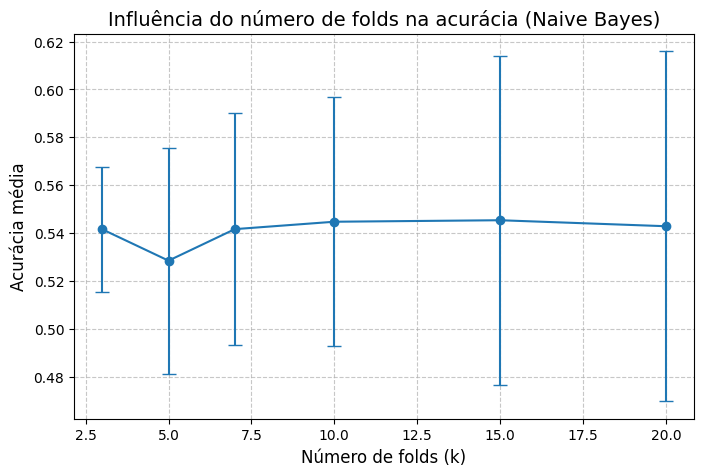

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt

folds = [3, 5, 7, 10, 15, 20]
mean_scores = []
std_scores = []

for k in folds:
	nb = GaussianNB()
	scores = cross_val_score(nb, X, y, cv=k, scoring='accuracy')
	mean_scores.append(scores.mean())
	std_scores.append(scores.std())
	print(f"{k} folds: Média da acurácia = {scores.mean():.4f}, Desvio padrão = {scores.std():.4f}")

plt.figure(figsize=(8, 5))
plt.errorbar(folds, mean_scores, yerr=std_scores, fmt='-o', capsize=5)
plt.xlabel('Número de folds (k)', fontsize=12)
plt.ylabel('Acurácia média', fontsize=12)
plt.title('Influência do número de folds na acurácia (Naive Bayes)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### 3 - Use validação cruzada para escolher o melhor valor de h no classificador bayesiano não paramétrico. Use a base Vehicle.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
import pandas as pd

dados = pd.read_csv(r'C:\Users\ashto\OneDrive\Documents\Python\Aprendizado_de_maquina\data\Vehicle.csv')
# Preparar os dados
X_vehicle = dados.iloc[:, :-1].values
y_vehicle = dados.iloc[:, -1].values
le = LabelEncoder()
y_vehicle_enc = le.fit_transform(y_vehicle)

# Classificador Bayesiano Não Paramétrico (Parzen Window)
class ParzenClassifier(BaseEstimator, ClassifierMixin):
	def __init__(self, bandwidth=1.0, kernel='gaussian'):
		self.bandwidth = bandwidth
		self.kernel = kernel

	def fit(self, X, y):
		self.classes_ = np.unique(y)
		self.models_ = []
		self.priors_ = []
		for c in self.classes_:
			X_c = X[y == c]
			kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
			kde.fit(X_c)
			self.models_.append(kde)
			self.priors_.append(len(X_c) / len(X))
		return self

	def predict(self, X):
		log_probs = []
		for kde, prior in zip(self.models_, self.priors_):
			log_prob = kde.score_samples(X) + np.log(prior)
			log_probs.append(log_prob)
		log_probs = np.vstack(log_probs).T
		return self.classes_[np.argmax(log_probs, axis=1)]

# Pipeline com padronização
pipe = make_pipeline(StandardScaler(), ParzenClassifier())

# Grid de valores de h (bandwidth)
param_grid = {'parzenclassifier__bandwidth': np.logspace(-2, 1, 15)}

# GridSearchCV com validação cruzada
gs = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gs.fit(X_vehicle, y_vehicle_enc)

print(f"Melhor valor de h (bandwidth): {gs.best_params_['parzenclassifier__bandwidth']:.4f}")
print(f"Melhor acurácia média na validação cruzada: {gs.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Melhor valor de h (bandwidth): 0.8483
Melhor acurácia média na validação cruzada: 0.7068
